For week 3, we did forward and backwards feature selection on our dataset. We also performed PCR vs PSLR.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


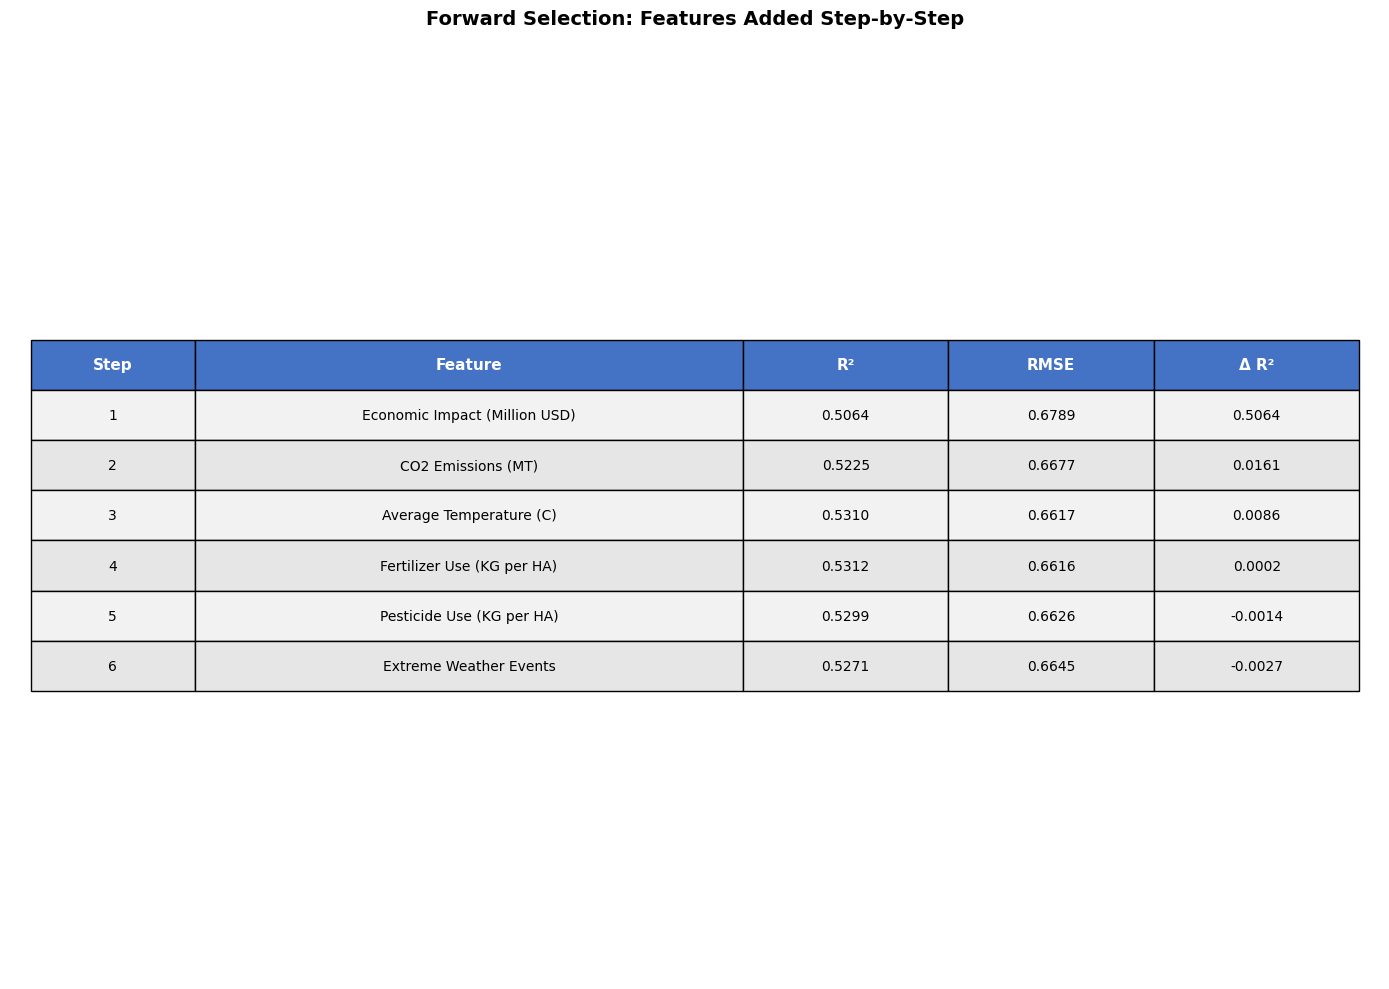


FORWARD SELECTION COMPLETE
 Step                       Feature     R²   RMSE    Δ R²
    1 Economic Impact (Million USD) 0.5064 0.6789  0.5064
    2            CO2 Emissions (MT) 0.5225 0.6677  0.0161
    3       Average Temperature (C) 0.5310 0.6617  0.0086
    4    Fertilizer Use (KG per HA) 0.5312 0.6616  0.0002
    5     Pesticide Use (KG per HA) 0.5299 0.6626 -0.0014
    6        Extreme Weather Events 0.5271 0.6645 -0.0027

Final selected features: 6
  1. Economic Impact (Million USD)
  2. CO2 Emissions (MT)
  3. Average Temperature (C)
  4. Fertilizer Use (KG per HA)
  5. Pesticide Use (KG per HA)
  6. Extreme Weather Events


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============ FORWARD SELECTION ============
selected_features = []
remaining_features = list(X.columns)
step_metrics = []

for step in range(1, min(len(X.columns) + 1, 16)):
    best_feature = None
    best_r2 = -np.inf
    best_rmse = None
    
    for feature in remaining_features:
        test_features = selected_features + [feature]
        model = LinearRegression()
        model.fit(X_train[test_features], y_train)
        y_pred = model.predict(X_test[test_features])
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if r2 > best_r2:
            best_r2 = r2
            best_feature = feature
            best_rmse = rmse
    
    if best_feature is not None:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        
        # Calculate improvement - using simple key names
        improvement = best_r2 - step_metrics[-1]['R2'] if step > 1 else best_r2
        
        step_metrics.append({
            'Step': step,
            'Feature': best_feature,
            'R2': best_r2,  # Store as number, not string
            'RMSE': best_rmse,  # Store as number, not string
            'R2_Improvement': improvement
        })

# ============ CONVERT TO DISPLAY DATAFRAME ============
display_df = pd.DataFrame({
    'Step': [m['Step'] for m in step_metrics],
    'Feature': [m['Feature'] for m in step_metrics],
    'R²': [f"{m['R2']:.4f}" for m in step_metrics],
    'RMSE': [f"{m['RMSE']:.4f}" for m in step_metrics],
    'Δ R²': [f"{m['R2_Improvement']:.4f}" for m in step_metrics]
})

# ============ VISUALIZATION TABLE ============
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.40, 0.15, 0.15, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(len(display_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Color rows
for i in range(1, len(display_df) + 1):
    if i % 2 == 0:
        color = '#E7E6E6'
    else:
        color = '#F2F2F2'
    
    for j in range(len(display_df.columns)):
        table[(i, j)].set_facecolor(color)

plt.title('Forward Selection: Features Added Step-by-Step', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FORWARD SELECTION COMPLETE")
print("="*80)
print(display_df.to_string(index=False))

# Summary
print(f"\nFinal selected features: {len(selected_features)}")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

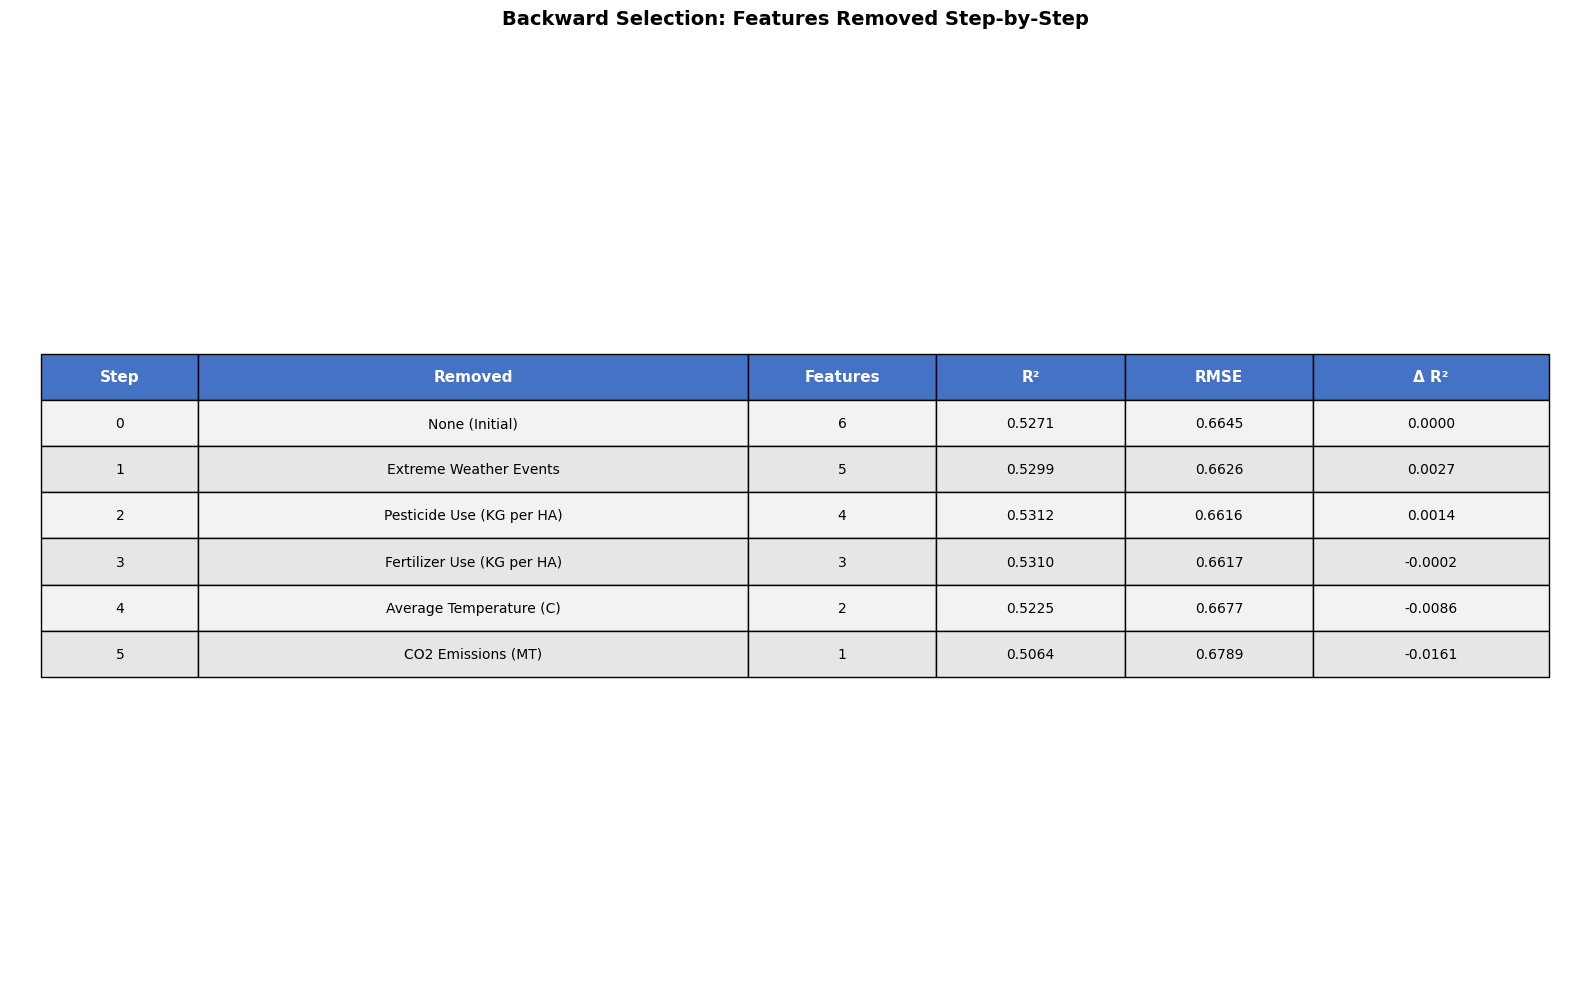


BACKWARD SELECTION COMPLETE
 Step                    Removed  Features     R²   RMSE    Δ R²
    0             None (Initial)         6 0.5271 0.6645  0.0000
    1     Extreme Weather Events         5 0.5299 0.6626  0.0027
    2  Pesticide Use (KG per HA)         4 0.5312 0.6616  0.0014
    3 Fertilizer Use (KG per HA)         3 0.5310 0.6617 -0.0002
    4    Average Temperature (C)         2 0.5225 0.6677 -0.0086
    5         CO2 Emissions (MT)         1 0.5064 0.6789 -0.0161

Final feature count: 1
Remaining features:
  1. Economic Impact (Million USD)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============ BACKWARD SELECTION ============
selected_features = list(X.columns)
step_metrics = []

# Track initial state
model = LinearRegression()
model.fit(X_train[selected_features], y_train)
y_pred = model.predict(X_test[selected_features])
initial_r2 = r2_score(y_test, y_pred)
initial_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

step_metrics.append({
    'Step': 0,
    'R2': initial_r2,
    'RMSE': initial_rmse,
    'R2_Change': 0.0,
    'Feature_Removed': 'None (Initial)',
    'Num_Features': len(selected_features)
})

# Backward elimination
for step in range(1, min(len(X.columns) + 1, 16)):
    best_feature_to_remove = None
    best_r2 = -np.inf
    best_rmse = None
    
    for feature in selected_features:
        test_features = [f for f in selected_features if f != feature]
        
        if len(test_features) == 0:
            continue
        
        model = LinearRegression()
        model.fit(X_train[test_features], y_train)
        y_pred = model.predict(X_test[test_features])
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if r2 > best_r2:
            best_r2 = r2
            best_feature_to_remove = feature
            best_rmse = rmse
    
    if best_feature_to_remove is not None:
        selected_features.remove(best_feature_to_remove)
        
        # Change in R² (degradation)
        r2_change = best_r2 - step_metrics[-1]['R2']
        
        step_metrics.append({
            'Step': step,
            'R2': best_r2,
            'RMSE': best_rmse,
            'R2_Change': r2_change,
            'Feature_Removed': best_feature_to_remove,
            'Num_Features': len(selected_features)
        })

# ============ CONVERT TO DISPLAY DATAFRAME ============
display_df = pd.DataFrame({
    'Step': [m['Step'] for m in step_metrics],
    'Removed': [m['Feature_Removed'] for m in step_metrics],
    'Features': [m['Num_Features'] for m in step_metrics],
    'R²': [f"{m['R2']:.4f}" for m in step_metrics],
    'RMSE': [f"{m['RMSE']:.4f}" for m in step_metrics],
    'Δ R²': [f"{m['R2_Change']:.4f}" for m in step_metrics]
})

# ============ VISUALIZATION TABLE ============
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.10, 0.35, 0.12, 0.12, 0.12, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.3)

# Color header
for i in range(len(display_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Color rows
for i in range(1, len(display_df) + 1):
    if i % 2 == 0:
        color = '#E7E6E6'
    else:
        color = '#F2F2F2'
    
    for j in range(len(display_df.columns)):
        table[(i, j)].set_facecolor(color)

plt.title('Backward Selection: Features Removed Step-by-Step', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BACKWARD SELECTION COMPLETE")
print("="*80)
print(display_df.to_string(index=False))

print(f"\nFinal feature count: {len(selected_features)}")
print(f"Remaining features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

In [5]:
# Step 1: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Step 2: Apply PCA
n_components = 3  # Reduce to 3 principal components
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
 
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_)}")
 
# Step 3: Fit linear regression on principal components
model = LinearRegression()
model.fit(X_train_pca, y_train)
 
# Step 4: Make predictions
y_train_pred = model.predict(X_train_pca)
y_test_pred = model.predict(X_test_pca)
 
# Step 5: Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
 
print(f"\nTraining RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
 
print(f"\nPCA Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")
 


Explained variance ratio: [0.20459783 0.17295337 0.17159067]
Cumulative explained variance: [0.20459783 0.37755119 0.54914186]

Training RMSE: 0.7459
Testing RMSE: 0.7270
Training R²: 0.3959
Testing R²: 0.4339

PCA Coefficients: [ 0.53187923 -0.0944862   0.08843462]
Intercept: 2.2372


In [6]:
print("\n" + "="*70)
print("PLSR (Partial Least Squares Regression)")
print("="*70)
 
from sklearn.cross_decomposition import PLSRegression
 
# PLSR finds components that maximize covariance with target (supervised)
n_components_pls = 3
pls_model = PLSRegression(n_components=n_components_pls)
pls_model.fit(X_train_scaled, y_train)
 
# Make predictions
y_train_pred_pls = pls_model.predict(X_train_scaled).flatten()
y_test_pred_pls = pls_model.predict(X_test_scaled).flatten()
 
# Evaluate PLSR
train_rmse_pls = np.sqrt(mean_squared_error(y_train, y_train_pred_pls))
test_rmse_pls = np.sqrt(mean_squared_error(y_test, y_test_pred_pls))
train_r2_pls = r2_score(y_train, y_train_pred_pls)
test_r2_pls = r2_score(y_test, y_test_pred_pls)
 
print(f"\nTraining RMSE: {train_rmse_pls:.4f}")
print(f"Testing RMSE: {test_rmse_pls:.4f}")
print(f"Training R²: {train_r2_pls:.4f}")
print(f"Testing R²: {test_r2_pls:.4f}")



PLSR (Partial Least Squares Regression)

Training RMSE: 0.6753
Testing RMSE: 0.6645
Training R²: 0.5048
Testing R²: 0.5271


In [7]:
print("\n" + "="*70)
print("PCR vs PLSR Comparison")
print("="*70)
 
comparison_df = pd.DataFrame({
    'Method': ['PCR', 'PLSR'],
    'Train RMSE': [train_rmse, train_rmse_pls],
    'Test RMSE': [test_rmse, test_rmse_pls],
    'Train R²': [train_r2, train_r2_pls],
    'Test R²': [test_r2, test_r2_pls]
})
 
print("\n", comparison_df.to_string(index=False))
 
print("\n\nKey Differences:")
print("- PCR: Unsupervised (PCA ignores target variable)")
print("- PLSR: Supervised (finds components maximizing covariance with target)")
print("- PLSR often performs better when target relationship is complex")


PCR vs PLSR Comparison

 Method  Train RMSE  Test RMSE  Train R²  Test R²
   PCR    0.745885   0.727038  0.395895 0.433915
  PLSR    0.675348   0.664492  0.504750 0.527124


Key Differences:
- PCR: Unsupervised (PCA ignores target variable)
- PLSR: Supervised (finds components maximizing covariance with target)
- PLSR often performs better when target relationship is complex


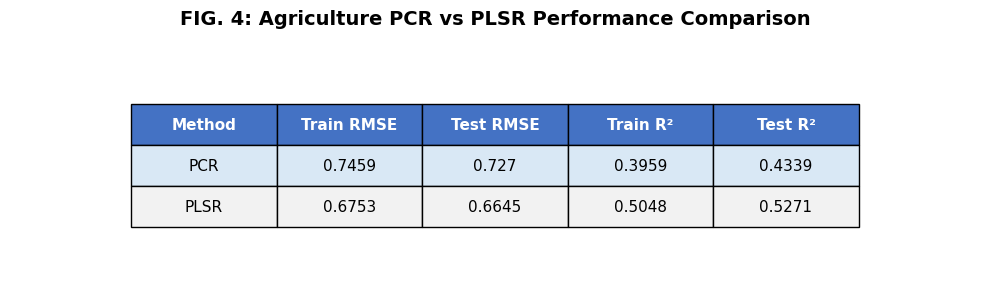



Key Differences:
- PCR: Unsupervised (PCA ignores target variable)
- PLSR: Supervised (finds components maximizing covariance with target)
- PLSR often performs better when target relationship is complex


In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
 
# Create table
table = ax.table(cellText=comparison_df.round(4).values,
                colLabels=comparison_df.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.15, 0.15, 0.15, 0.15])
 
# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)
 
# Color header row
for i in range(len(comparison_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')
 
# Color data rows with alternating colors
colors = ['#D9E8F5', '#F2F2F2']
for i in range(1, len(comparison_df) + 1):
    for j in range(len(comparison_df.columns)):
        table[(i, j)].set_facecolor(colors[(i-1) % 2])
 
plt.title('FIG. 4: Agriculture PCR vs PLSR Performance Comparison', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
 
print("\n\nKey Differences:")
print("- PCR: Unsupervised (PCA ignores target variable)")
print("- PLSR: Supervised (finds components maximizing covariance with target)")
print("- PLSR often performs better when target relationship is complex")

In [9]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


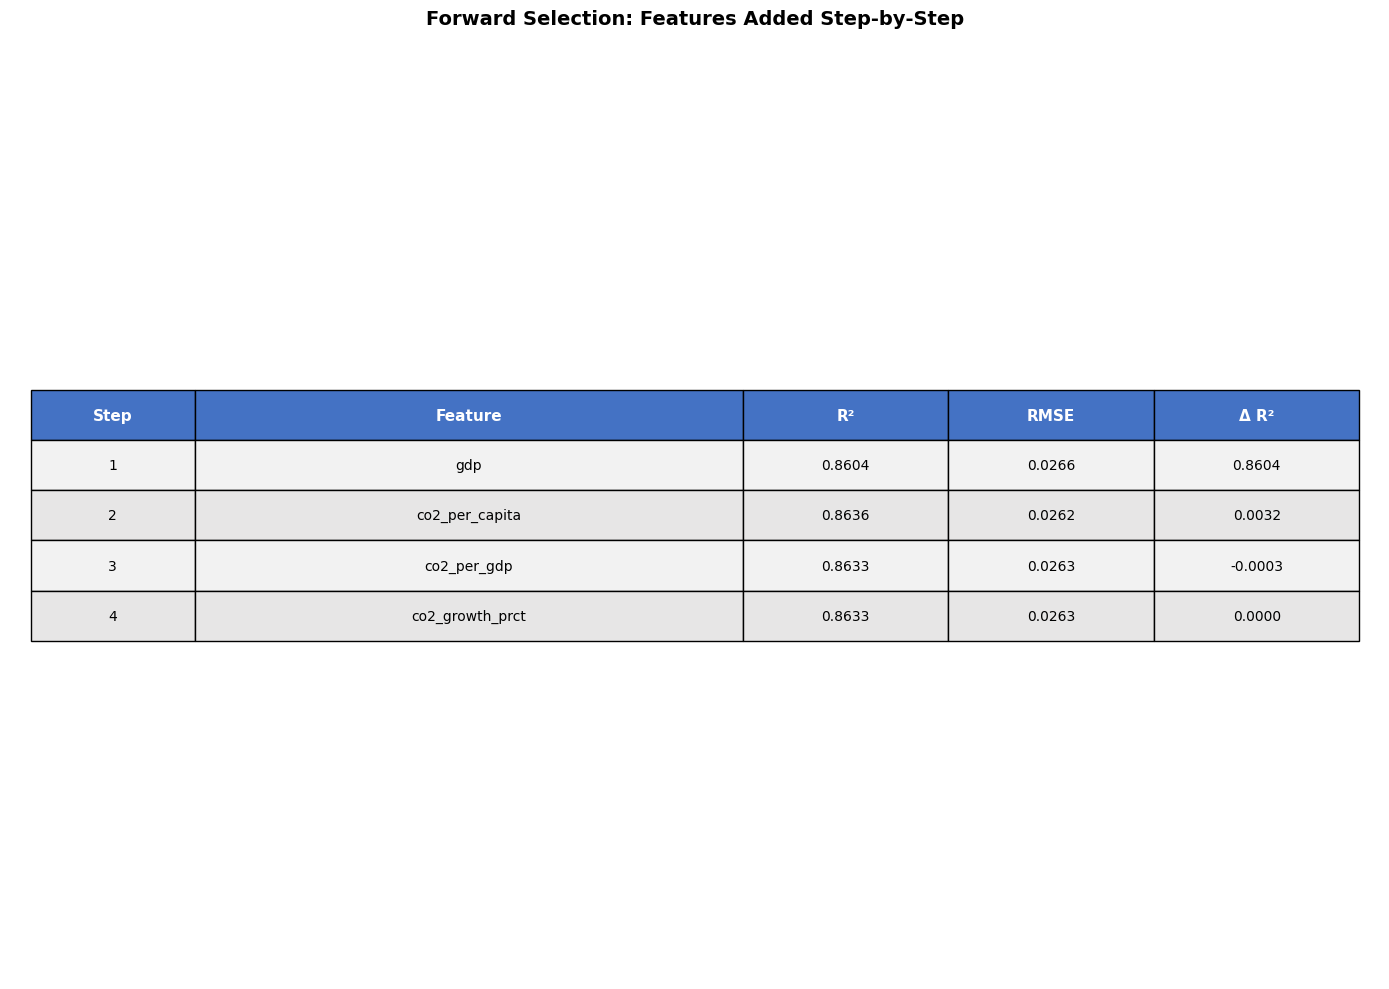


FORWARD SELECTION COMPLETE
 Step         Feature     R²   RMSE    Δ R²
    1             gdp 0.8604 0.0266  0.8604
    2  co2_per_capita 0.8636 0.0262  0.0032
    3     co2_per_gdp 0.8633 0.0263 -0.0003
    4 co2_growth_prct 0.8633 0.0263  0.0000

Final selected features: 4
  1. gdp
  2. co2_per_capita
  3. co2_per_gdp
  4. co2_growth_prct


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
y = clean_numeric_dfCO2["temperature_change_from_co2"]
X = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============ FORWARD SELECTION ============
selected_features = []
remaining_features = list(X.columns)
step_metrics = []

for step in range(1, min(len(X.columns) + 1, 16)):
    best_feature = None
    best_r2 = -np.inf
    best_rmse = None
    
    for feature in remaining_features:
        test_features = selected_features + [feature]
        model = LinearRegression()
        model.fit(X_train[test_features], y_train)
        y_pred = model.predict(X_test[test_features])
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if r2 > best_r2:
            best_r2 = r2
            best_feature = feature
            best_rmse = rmse
    
    if best_feature is not None:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        
        # Calculate improvement - using simple key names
        improvement = best_r2 - step_metrics[-1]['R2'] if step > 1 else best_r2
        
        step_metrics.append({
            'Step': step,
            'Feature': best_feature,
            'R2': best_r2,  # Store as number, not string
            'RMSE': best_rmse,  # Store as number, not string
            'R2_Improvement': improvement
        })

# ============ CONVERT TO DISPLAY DATAFRAME ============
display_df = pd.DataFrame({
    'Step': [m['Step'] for m in step_metrics],
    'Feature': [m['Feature'] for m in step_metrics],
    'R²': [f"{m['R2']:.4f}" for m in step_metrics],
    'RMSE': [f"{m['RMSE']:.4f}" for m in step_metrics],
    'Δ R²': [f"{m['R2_Improvement']:.4f}" for m in step_metrics]
})

# ============ VISUALIZATION TABLE ============
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.40, 0.15, 0.15, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(len(display_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Color rows
for i in range(1, len(display_df) + 1):
    if i % 2 == 0:
        color = '#E7E6E6'
    else:
        color = '#F2F2F2'
    
    for j in range(len(display_df.columns)):
        table[(i, j)].set_facecolor(color)

plt.title('Forward Selection: Features Added Step-by-Step', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FORWARD SELECTION COMPLETE")
print("="*80)
print(display_df.to_string(index=False))

# Summary
print(f"\nFinal selected features: {len(selected_features)}")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

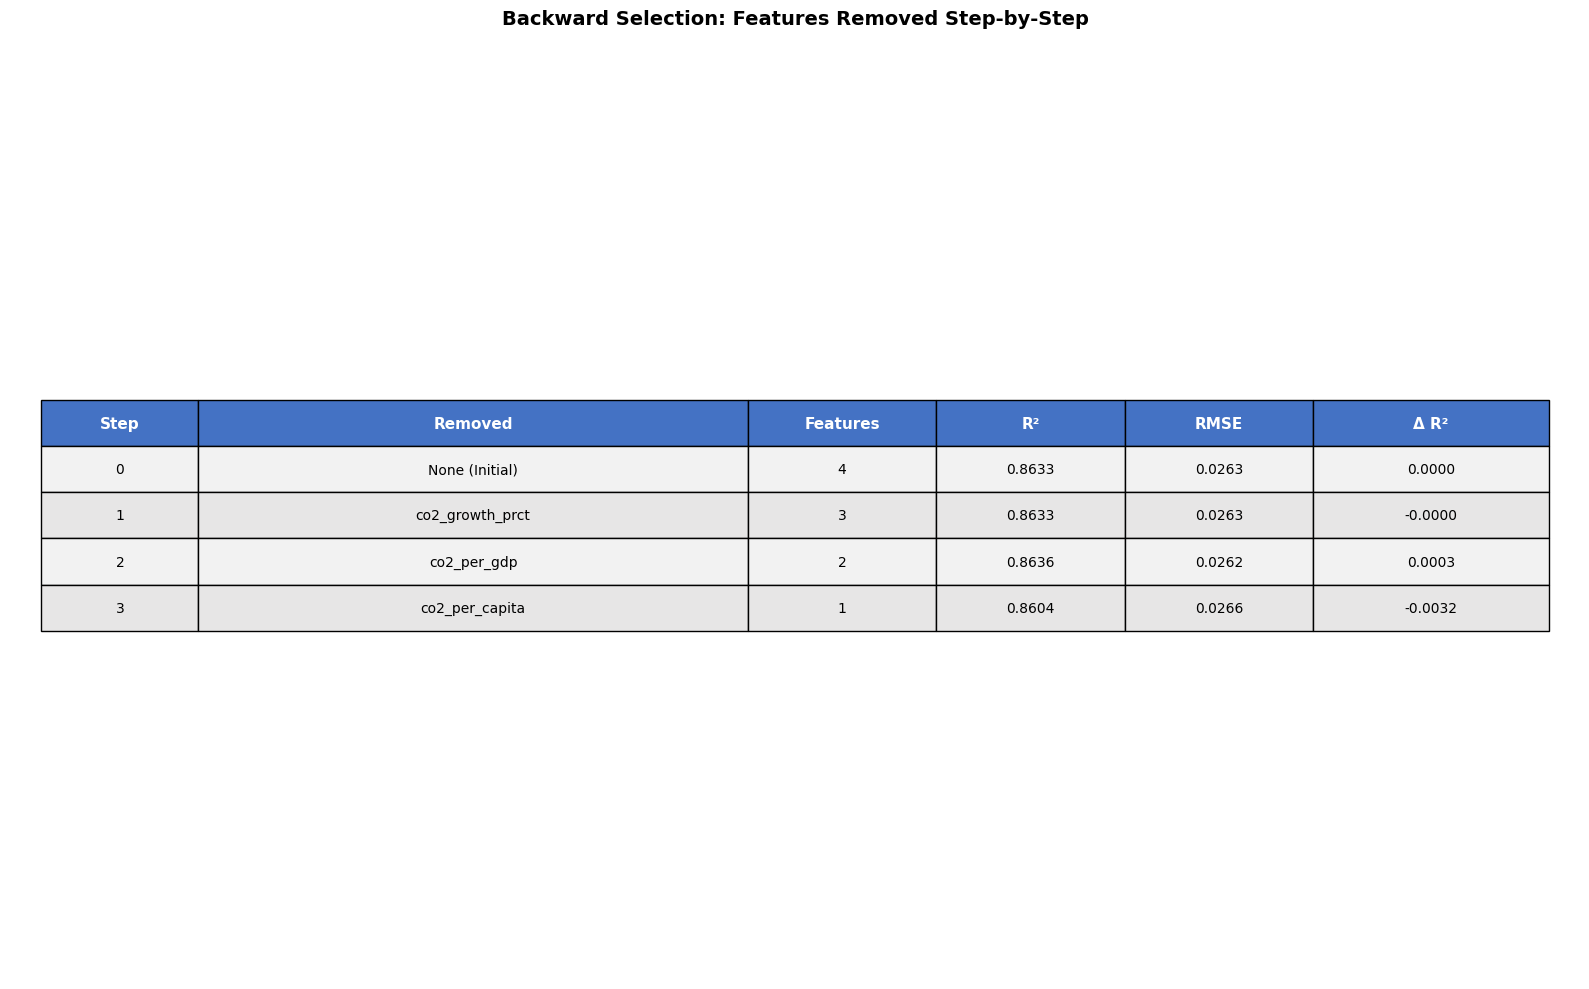


BACKWARD SELECTION COMPLETE
 Step         Removed  Features     R²   RMSE    Δ R²
    0  None (Initial)         4 0.8633 0.0263  0.0000
    1 co2_growth_prct         3 0.8633 0.0263 -0.0000
    2     co2_per_gdp         2 0.8636 0.0262  0.0003
    3  co2_per_capita         1 0.8604 0.0266 -0.0032

Final feature count: 1
Remaining features:
  1. gdp


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
y = clean_numeric_dfCO2["temperature_change_from_co2"]
X = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============ BACKWARD SELECTION ============
selected_features = list(X.columns)
step_metrics = []

# Track initial state
model = LinearRegression()
model.fit(X_train[selected_features], y_train)
y_pred = model.predict(X_test[selected_features])
initial_r2 = r2_score(y_test, y_pred)
initial_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

step_metrics.append({
    'Step': 0,
    'R2': initial_r2,
    'RMSE': initial_rmse,
    'R2_Change': 0.0,
    'Feature_Removed': 'None (Initial)',
    'Num_Features': len(selected_features)
})

# Backward elimination
for step in range(1, min(len(X.columns) + 1, 16)):
    best_feature_to_remove = None
    best_r2 = -np.inf
    best_rmse = None
    
    for feature in selected_features:
        test_features = [f for f in selected_features if f != feature]
        
        if len(test_features) == 0:
            continue
        
        model = LinearRegression()
        model.fit(X_train[test_features], y_train)
        y_pred = model.predict(X_test[test_features])
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if r2 > best_r2:
            best_r2 = r2
            best_feature_to_remove = feature
            best_rmse = rmse
    
    if best_feature_to_remove is not None:
        selected_features.remove(best_feature_to_remove)
        
        # Change in R² (degradation)
        r2_change = best_r2 - step_metrics[-1]['R2']
        
        step_metrics.append({
            'Step': step,
            'R2': best_r2,
            'RMSE': best_rmse,
            'R2_Change': r2_change,
            'Feature_Removed': best_feature_to_remove,
            'Num_Features': len(selected_features)
        })

# ============ CONVERT TO DISPLAY DATAFRAME ============
display_df = pd.DataFrame({
    'Step': [m['Step'] for m in step_metrics],
    'Removed': [m['Feature_Removed'] for m in step_metrics],
    'Features': [m['Num_Features'] for m in step_metrics],
    'R²': [f"{m['R2']:.4f}" for m in step_metrics],
    'RMSE': [f"{m['RMSE']:.4f}" for m in step_metrics],
    'Δ R²': [f"{m['R2_Change']:.4f}" for m in step_metrics]
})

# ============ VISUALIZATION TABLE ============
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.10, 0.35, 0.12, 0.12, 0.12, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.3)

# Color header
for i in range(len(display_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Color rows
for i in range(1, len(display_df) + 1):
    if i % 2 == 0:
        color = '#E7E6E6'
    else:
        color = '#F2F2F2'
    
    for j in range(len(display_df.columns)):
        table[(i, j)].set_facecolor(color)

plt.title('Backward Selection: Features Removed Step-by-Step', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BACKWARD SELECTION COMPLETE")
print("="*80)
print(display_df.to_string(index=False))

print(f"\nFinal feature count: {len(selected_features)}")
print(f"Remaining features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

In [12]:
# Step 1: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Step 2: Apply PCA
n_components = 3  # Reduce to 3 principal components
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
 
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_)}")
 
# Step 3: Fit linear regression on principal components
model = LinearRegression()
model.fit(X_train_pca, y_train)
 
# Step 4: Make predictions
y_train_pred = model.predict(X_train_pca)
y_test_pred = model.predict(X_test_pca)
 
# Step 5: Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
 
print(f"\nTraining RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
 
print(f"\nPCA Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")


Explained variance ratio: [0.33924908 0.26363242 0.24332722]
Cumulative explained variance: [0.33924908 0.60288149 0.84620871]

Training RMSE: 0.0163
Testing RMSE: 0.0260
Training R²: 0.9747
Testing R²: 0.8662

PCA Coefficients: [-0.00482557  0.05472516  0.08511393]
Intercept: 0.0241


In [13]:
print("\n" + "="*70)
print("PLSR (Partial Least Squares Regression)")
print("="*70)
 
from sklearn.cross_decomposition import PLSRegression
 
# PLSR finds components that maximize covariance with target (supervised)
n_components_pls = 3
pls_model = PLSRegression(n_components=n_components_pls)
pls_model.fit(X_train_scaled, y_train)
 
# Make predictions
y_train_pred_pls = pls_model.predict(X_train_scaled).flatten()
y_test_pred_pls = pls_model.predict(X_test_scaled).flatten()
 
# Evaluate PLSR
train_rmse_pls = np.sqrt(mean_squared_error(y_train, y_train_pred_pls))
test_rmse_pls = np.sqrt(mean_squared_error(y_test, y_test_pred_pls))
train_r2_pls = r2_score(y_train, y_train_pred_pls)
test_r2_pls = r2_score(y_test, y_test_pred_pls)
 
print(f"\nTraining RMSE: {train_rmse_pls:.4f}")
print(f"Testing RMSE: {test_rmse_pls:.4f}")
print(f"Training R²: {train_r2_pls:.4f}")
print(f"Testing R²: {test_r2_pls:.4f}")


PLSR (Partial Least Squares Regression)

Training RMSE: 0.0161
Testing RMSE: 0.0260
Training R²: 0.9754
Testing R²: 0.8657


In [14]:
print("\n" + "="*70)
print("PCR vs PLSR Comparison")
print("="*70)
 
comparison_df = pd.DataFrame({
    'Method': ['PCR', 'PLSR'],
    'Train RMSE': [train_rmse, train_rmse_pls],
    'Test RMSE': [test_rmse, test_rmse_pls],
    'Train R²': [train_r2, train_r2_pls],
    'Test R²': [test_r2, test_r2_pls]
})
 
print("\n", comparison_df.to_string(index=False))
 
print("\n\nKey Differences:")
print("- PCR: Unsupervised (PCA ignores target variable)")
print("- PLSR: Supervised (finds components maximizing covariance with target)")
print("- PLSR often performs better when target relationship is complex")


PCR vs PLSR Comparison

 Method  Train RMSE  Test RMSE  Train R²  Test R²
   PCR    0.016310   0.025998  0.974681 0.866203
  PLSR    0.016062   0.026048  0.975446 0.865689


Key Differences:
- PCR: Unsupervised (PCA ignores target variable)
- PLSR: Supervised (finds components maximizing covariance with target)
- PLSR often performs better when target relationship is complex
